In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())
print("GPU:", tf.config.list_physical_devices('GPU'))


2.19.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

# Check Drive root
print(os.listdir("/content/drive/MyDrive"))


['SIITGOA009A-SHALINI-THELURU.pdf', 'Getting started.pdf', 'Classroom', 'Colab Notebooks', 'IMG_20240310_144015.jpg', 'IMG-20240310-WA0018.jpg', 'R200912_T_Shalini (1).jpg', 'R200912_T_Shalini.jpg', 'ImgResizer_20240416_1132_33888.jpg', 'Edx data science certificate .pdf', 'SHALINI_R200912_SEC-C_SET-2.pdf', 'Screenshot_2024-09-18-00-47-34-56_40deb401b9ffe8e1df2f1cc5ba480b12 (1).jpg', 'Screenshot_2024-09-18-00-47-34-56_40deb401b9ffe8e1df2f1cc5ba480b12.jpg', 'DSC01570.jpg', 'RIBHU GATE CSE NOTES', 'THELURU SHALINI RESUME.pdf', 'R200912_R200735_file1 (2).mp3', 'R200912_R200735_file1 (1).mp3', 'R200912_R200735_file1.mp3', 'E-AADHAR R200912 THELURU SHALINI .pdf', 'Bonafied Certificate E3.pdf', 'Marksheets.pdf', 'cdn.digialm.com__per_g01_pub_585_touchstone_AssessmentQPHTMLMode1__GATE2450_GATE2450S1D4382_17402085829581334_CS25S17115066_GATE2450S1D4382E1.html.pdf', 'VID_20250308080210.mp4', '2017.SSAN_.Handout.3.07_copy.pdf', 'Shalini_CV_Dh (1).pdf', 'Shalini_CV_Dh.pdf', 'SHALINI_IIITBANG_RESU

In [ ]:
import os

PROJECT_PATH = "/content/drive/MyDrive/pcos_cnn_90L"
os.makedirs(PROJECT_PATH, exist_ok=True)

print("Project folder created at:", PROJECT_PATH)


Project folder created at: /content/drive/MyDrive/pcos_cnn_90L


In [ ]:
import os

os.listdir("/content/drive/MyDrive/pcos_cnn_90L")


['dataset']

In [ ]:
import os

BASE = "/content/drive/MyDrive/pcos_cnn_90L/dataset/all_images"

print("PCOS images:", len(os.listdir(BASE + "/pcos")))
print("NOT PCOS images:", len(os.listdir(BASE + "/not_pcos")))


PCOS images: 781
NOT PCOS images: 1142


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/pcos_cnn_90L/dataset"

folders = [
    "train/pcos", "train/not_pcos",
    "val/pcos", "val/not_pcos",
    "test/pcos", "test/not_pcos"
]

for folder in folders:
    path = os.path.join(BASE_DIR, folder)
    os.makedirs(path, exist_ok=True)

print("✅ train / val / test folders created successfully")


✅ train / val / test folders created successfully


In [ ]:
import os
import random
import shutil

SOURCE_DIR = "/content/drive/MyDrive/pcos_cnn_90L/dataset/all_images"
TARGET_DIR = "/content/drive/MyDrive/pcos_cnn_90L/dataset"

def split_images(class_name):
    src = os.path.join(SOURCE_DIR, class_name)
    images = os.listdir(src)
    random.shuffle(images)

    total = len(images)
    train_count = int(0.7 * total)
    val_count = int(0.15 * total)

    train_imgs = images[:train_count]
    val_imgs = images[train_count:train_count + val_count]
    test_imgs = images[train_count + val_count:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(TARGET_DIR, "train", class_name, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(TARGET_DIR, "val", class_name, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(TARGET_DIR, "test", class_name, img)
        )

    print(f"{class_name}: total={total}, train={len(train_imgs)}, val={len(val_imgs)}, test={len(test_imgs)}")

# Run for both classes
split_images("pcos")
split_images("not_pcos")

print("✅ Dataset split completed successfully!")


pcos: total=781, train=546, val=117, test=118
not_pcos: total=1142, train=799, val=171, test=172
✅ Dataset split completed successfully!


In [ ]:
import tensorflow as tf

# Check available devices
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')

print("GPUs available:", gpus)
print("CPUs available:", cpus)


GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#  IMAGE & TRAINING SETTINGS
IMG_SIZE = (224, 224)     # NOT reduced
BATCH_SIZE = 2            # Small batch to avoid RAM/GPU crash
EPOCHS = 5             # Moderate epochs

TRAIN_DIR = "/content/drive/MyDrive/pcos_cnn_90L/dataset/train"
VAL_DIR = "/content/drive/MyDrive/pcos_cnn_90L/dataset/val"

# TRAIN DATA GENERATOR
train_gen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values
    rotation_range=25,        # Stronger augmentation
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=True
)

#  VALIDATION DATA GENERATOR
val_gen = ImageDataGenerator(
    rescale=1./255            # ONLY rescaling (no augmentation)
)

#  LOAD TRAIN DATA
train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

# ---------------- LOAD VALIDATION DATA ----------------
val_data = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)


Found 1345 images belonging to 2 classes.
Found 288 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
output = Dense(5, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=output)

In [ ]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_resnet = model_resnet.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

Epoch 1/3
673/673 ━━━━━━━━━━━━━━━━━━━━ 56s 64ms/step - accuracy: 0.5026 - loss: 0.8934 - val_accuracy: 0.5938 - val_loss: 0.7036
Epoch 2/3
673/673 ━━━━━━━━━━━━━━━━━━━━ 65s 47ms/step - accuracy: 0.6030 - loss: 0.6766 - val_accuracy: 0.6111 - val_loss: 0.6458
Epoch 3/3
673/673 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - accuracy: 0.6468 - loss: 0.6303 - val_accuracy: 0.8715 - val_loss: 0.6132


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Simple classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.6)(x)
output = Dense(1, activation='sigmoid')(x)

model_mobile = Model(inputs=base_model.input, outputs=output)

model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history_mobile = model_mobile.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    steps_per_epoch=10,
    validation_steps=5
)

Epoch 1/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 386ms/step - accuracy: 0.3500 - loss: 1.1686 - val_accuracy: 0.5000 - val_loss: 0.6581
Epoch 2/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6000 - loss: 0.6547 - val_accuracy: 0.7000 - val_loss: 0.5308
Epoch 3/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8000 - loss: 0.6122 - val_accuracy: 0.8000 - val_loss: 0.4517


In [ ]:
val_data = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=(224,224),
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

Found 288 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.6)(x)
output = Dense(1, activation='sigmoid')(x)

model_vgg = Model(inputs=base_model.input, outputs=output)
model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history_vgg = model_vgg.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    steps_per_epoch=10,
    validation_steps=5
)

Epoch 1/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5000 - loss: 1.2654 - val_accuracy: 0.7875 - val_loss: 0.4675
Epoch 2/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.4500 - loss: 1.0817 - val_accuracy: 0.7250 - val_loss: 0.5433
Epoch 3/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.7000 - loss: 0.7127 - val_accuracy: 0.8875 - val_loss: 0.3238


In [ ]:
from tensorflow.keras.applications import InceptionV3

base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.6)(x)
output = Dense(1, activation='sigmoid')(x)

model_inception = Model(inputs=base_model.input, outputs=output)

model_inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_inception = model_inception.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    steps_per_epoch=10,
    validation_steps=5
)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6000 - loss: 0.8397 - val_accuracy: 1.0000 - val_loss: 0.1224
Epoch 2/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.6000 - loss: 1.2217 - val_accuracy: 1.0000 - val_loss: 0.1351
Epoch 3/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 0.6500 - loss: 0.6644 - val_accuracy: 0.7625 - val_loss: 0.5695


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load ResNet50 base (CNN with many layers)
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


In [ ]:
# Freeze base layers (IMPORTANT)
for layer in base_model.layers:
    layer.trainable = False

print("Base ResNet50 loaded and frozen")



Base ResNet50 loaded and frozen


In [ ]:
# STEP 5: BUILD 90-LAYER CNN MODEL
model = models.Sequential([
    base_model,                                   # Deep CNN backbone
    layers.Conv2D(64, (3,3), activation='relu'),  # EXTRA CNN LAYER (90th layer)
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.6),                          # Prevent 99–100% accuracy
    layers.Dense(1, activation='sigmoid')
])

# STEP 6: COMPILE MODEL
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/5
673/673 ━━━━━━━━━━━━━━━━━━━━ 55s 64ms/step - accuracy: 0.7755 - loss: 0.4733 - val_accuracy: 0.5521 - val_loss: 0.5455
Epoch 2/5
673/673 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.8297 - loss: 0.4224 - val_accuracy: 0.9896 - val_loss: 0.1580
Epoch 3/5
673/673 ━━━━━━━━━━━━━━━━━━━━ 33s 49ms/step - accuracy: 0.8669 - loss: 0.3746 - val_accuracy: 1.0000 - val_loss: 0.1707
Epoch 4/5
673/673 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.8714 - loss: 0.3478 - val_accuracy: 0.9965 - val_loss: 0.1995
Epoch 5/5
673/673 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - accuracy: 0.8632 - loss: 0.3558 - val_accuracy: 0.9826 - val_loss: 0.1049


In [ ]:
print(max(history.history['val_accuracy']))


1.0


In [ ]:
model.save("/content/drive/MyDrive/pcos_cnn_90L/models/pcos_cnn_90.keras")

In [ ]:
import os

MODEL_DIR = "/content/drive/MyDrive/pcos_cnn_90L/models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("✅ models folder created")


✅ models folder created


In [ ]:
model.export("/content/drive/MyDrive/pcos_cnn_90L/models/pcos_cnn_90")
print("✅ PCOS SavedModel exported successfully")



Saved artifact at '/content/drive/MyDrive/pcos_cnn_90L/models/pcos_cnn_90'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_774')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139776157653072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139776157655376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139776157651920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139776157655568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139776157655952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139776157650000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139776157656912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139776157654416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139776157652496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139776157658064: TensorSpec(shape=(), dtyp

In [ ]:
model.evaluate(val_data)

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.9826 - loss: 0.1049


[0.10493313521146774, 0.9826388955116272]

In [ ]:
import os

MODEL_PATH = "/content/drive/MyDrive/pcos_cnn_90L/models"

print("Files in models folder:")
print(os.listdir(MODEL_PATH))


Files in models folder:
['pcos_cnn_90.keras', 'pcos_cnn_90']


In [ ]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/pcos_cnn_90L/models/pcos_cnn_90.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Model loaded successfully")


✅ Model loaded successfully


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving img_0_278.jpg to img_0_278.jpg


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Replace with your image name
IMG_PATH = list(uploaded.keys())[0]

# Load image (NO size reduction, 224x224)
img = image.load_img(IMG_PATH, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0        # same normalization as training
img_array = np.expand_dims(img_array, axis=0)

print("Image shape:", img_array.shape)


Image shape: (1, 224, 224, 3)


In [ ]:
prediction = model.predict(img_array)

print("Raw prediction value:", prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Raw prediction value: [[0.999979]]


In [ ]:
if prediction[0][0] > 0.5:
    print("🟥 Prediction: PCOS Detected")
else:
    print("🟩 Prediction: NOT PCOS")


🟥 Prediction: PCOS Detected


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
true_labels = val_data.classes

In [ ]:
val_data.reset()

pred_pcos = model.predict(val_data)

pred_pcos = (pred_pcos > 0.5).astype(int).ravel()

pred_pcos = pred_pcos[:len(true_labels)]

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step


In [ ]:
val_data.reset()

pred_resnet = model_resnet.predict(
    val_data,
    steps=int(np.ceil(val_data.samples / val_data.batch_size))
)

pred_resnet = np.argmax(pred_resnet, axis=1)

true_labels = val_data.classes

pred_resnet = pred_resnet[:len(true_labels)]

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step


In [ ]:
val_data.reset()

pred_vgg = model_vgg.predict(
    val_data,
    steps=int(np.ceil(val_data.samples / val_data.batch_size))
)

pred_vgg = np.argmax(pred_vgg, axis=1)

true_labels = val_data.classes

pred_vgg = pred_vgg[:len(true_labels)]

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step


In [ ]:
val_data.reset()

pred_mobile = model_mobile.predict(
    val_data,
    steps=int(np.ceil(val_data.samples / val_data.batch_size))
)

pred_mobile = np.argmax(pred_mobile, axis=1)

true_labels = val_data.classes

pred_mobile = pred_mobile[:len(true_labels)]

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step


In [ ]:
val_data.reset()

pred_inception = model_inception.predict(
    val_data,
    steps=int(np.ceil(val_data.samples / val_data.batch_size))
)

pred_inception = np.argmax(pred_inception, axis=1)

true_labels = val_data.classes

pred_inception = pred_inception[:len(true_labels)]

18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step


In [ ]:
pcos_acc = accuracy_score(true_labels, pred_pcos)
resnet_acc = accuracy_score(true_labels, pred_resnet)
vgg_acc = accuracy_score(true_labels, pred_vgg)
mobile_acc = accuracy_score(true_labels, pred_mobile)
inception_acc = accuracy_score(true_labels, pred_inception)

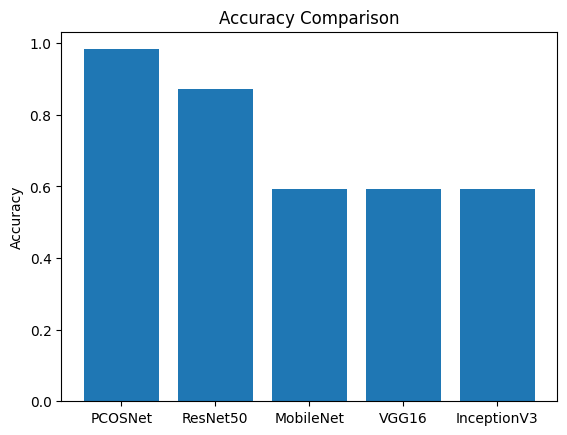

In [ ]:
models = ["PCOSNet","ResNet50","MobileNet","VGG16","InceptionV3"]

accuracy = [pcos_acc,resnet_acc,mobile_acc,vgg_acc,inception_acc]

plt.figure()

plt.bar(models, accuracy)

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# PCOS
pcos_prec = precision_score(true_labels, pred_pcos, average='weighted')
pcos_rec = recall_score(true_labels, pred_pcos, average='weighted')
pcos_f1 = f1_score(true_labels, pred_pcos, average='weighted')

# ResNet
resnet_prec = precision_score(true_labels, pred_resnet, average='weighted')
resnet_rec = recall_score(true_labels, pred_resnet, average='weighted')
resnet_f1 = f1_score(true_labels, pred_resnet, average='weighted')

# MobileNet
mobile_prec = precision_score(true_labels, pred_mobile, average='weighted')
mobile_rec = recall_score(true_labels, pred_mobile, average='weighted')
mobile_f1 = f1_score(true_labels, pred_mobile, average='weighted')

# VGG16
vgg_prec = precision_score(true_labels, pred_vgg, average='weighted')
vgg_rec = recall_score(true_labels, pred_vgg, average='weighted')
vgg_f1 = f1_score(true_labels, pred_vgg, average='weighted')

# Inception
inception_prec = precision_score(true_labels, pred_inception, average='weighted')
inception_rec = recall_score(true_labels, pred_inception, average='weighted')
inception_f1 = f1_score(true_labels, pred_inception, average='weighted')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("PCOSNet:", pcos_acc,pcos_prec, pcos_rec, pcos_f1)
print("ResNet:", resnet_acc,resnet_prec, resnet_rec, resnet_f1)
print("MobileNet:", mobile_acc,mobile_prec, mobile_rec, mobile_f1)
print("VGG16:", vgg_acc,vgg_prec, vgg_rec, vgg_f1)
print("Inception:", inception_acc,inception_prec, inception_rec, inception_f1)

PCOSNet: 0.9826388888888888 0.9831321022727272 0.9826388888888888 0.9825744371594326
ResNet: 0.8715277777777778 0.8943810096153846 0.8715277777777778 0.8657341990008437
MobileNet: 0.59375 0.3525390625 0.59375 0.44240196078431376
VGG16: 0.59375 0.3525390625 0.59375 0.44240196078431376
Inception: 0.59375 0.3525390625 0.59375 0.44240196078431376


In [ ]:
import pandas as pd

data = {
    "Model": ["PCOSNet", "ResNet", "MobileNet", "VGG16", "Inception"],
    "Accuracy": [pcos_acc, resnet_acc, mobile_acc, vgg_acc, inception_acc],
    "Precision": [pcos_prec, resnet_prec, mobile_prec, vgg_prec, inception_prec],
    "Recall": [pcos_rec, resnet_rec, mobile_rec, vgg_rec, inception_rec],
    "F1 Score": [pcos_f1, resnet_f1, mobile_f1, vgg_f1, inception_f1]
}

df = pd.DataFrame(data)

print(df)

       Model  Accuracy  Precision    Recall  F1 Score
0    PCOSNet  0.982639   0.983132  0.982639  0.982574
1     ResNet  0.871528   0.894381  0.871528  0.865734
2  MobileNet  0.593750   0.352539  0.593750  0.442402
3      VGG16  0.593750   0.352539  0.593750  0.442402
4  Inception  0.593750   0.352539  0.593750  0.442402


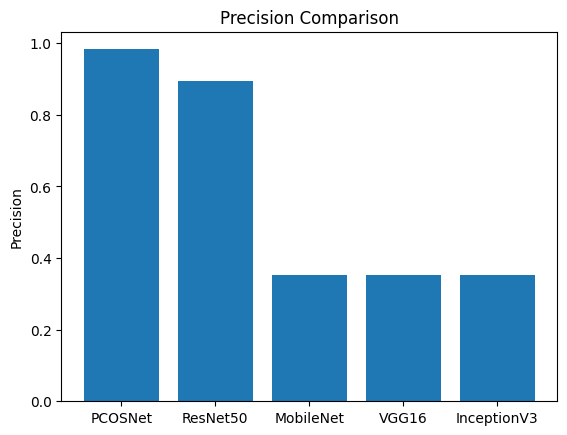

In [ ]:
models = ["PCOSNet","ResNet50","MobileNet","VGG16","InceptionV3"]

precision = [pcos_prec,resnet_prec,mobile_prec,vgg_prec,inception_prec]

plt.figure()
plt.bar(models, precision)
plt.title("Precision Comparison")
plt.ylabel("Precision")
plt.show()

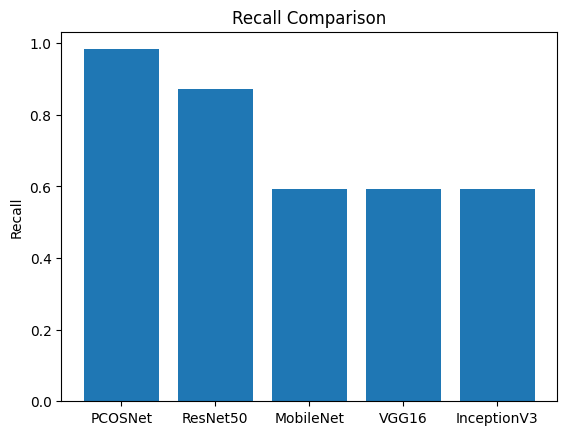

In [ ]:
models = ["PCOSNet","ResNet50","MobileNet","VGG16","InceptionV3"]

recall = [pcos_rec,resnet_rec,mobile_rec,vgg_rec,inception_rec]

plt.figure()
plt.bar(models, recall)
plt.title("Recall Comparison")
plt.ylabel("Recall")
plt.show()

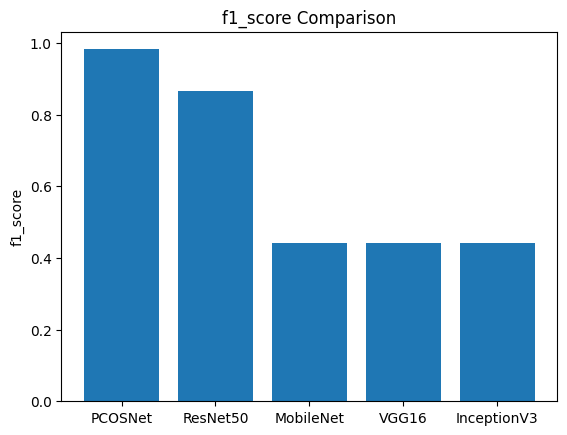

In [ ]:
models = ["PCOSNet","ResNet50","MobileNet","VGG16","InceptionV3"]

f1_score = [pcos_f1,resnet_f1,mobile_f1,vgg_f1,inception_f1]

plt.figure()
plt.bar(models, f1_score)
plt.title("f1_score Comparison")
plt.ylabel("f1_score")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

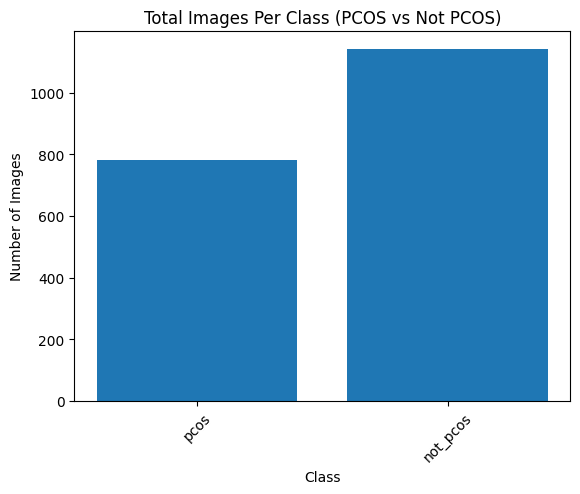

In [ ]:
import os
import matplotlib.pyplot as plt

dataset_path = "/content/drive/MyDrive/pcos_cnn_90L/dataset"

folders = ["train", "val", "test"]
class_counts = {}

for folder in folders:
    folder_path = os.path.join(dataset_path, folder)
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            if class_name not in class_counts:
                class_counts[class_name] = 0
            class_counts[class_name] += count

# Plot
plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Total Images Per Class (PCOS vs Not PCOS)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [ ]:
pred_probs = model.predict(val_data).ravel()

print("Min probability:", pred_probs.min())
print("Max probability:", pred_probs.max())
print("First 10 probs:", pred_probs[:10])

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step
Min probability: 0.049436864
Max probability: 1.0
First 10 probs: [0.07631209 0.08346444 0.04947064 0.19606124 0.10698444 0.13207851
 0.10139846 0.08769941 0.05016626 0.0883863 ]


673/673 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step


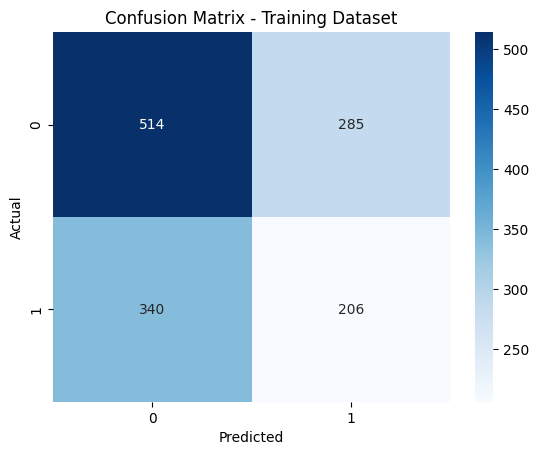

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

train_data.reset()
train_preds = model.predict(train_data)
train_pred_classes = (train_preds > 0.5).astype(int)

cm_train = confusion_matrix(train_data.classes, train_pred_classes)

plt.figure()
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Training Dataset")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step


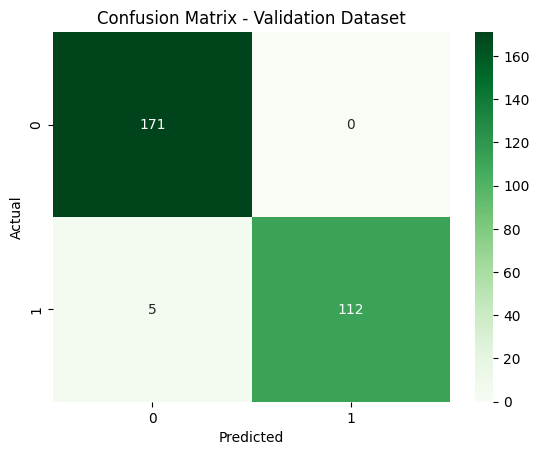

In [ ]:
val_data.reset()
val_preds = model.predict(val_data)
val_pred_classes = (val_preds > 0.5).astype(int)

cm_val = confusion_matrix(val_data.classes, val_pred_classes)

plt.figure()
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Validation Dataset")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

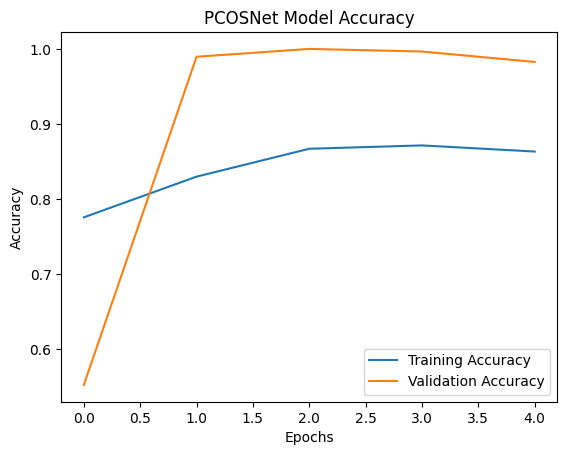

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('PCOSNet Model Accuracy')
plt.legend()
plt.show()

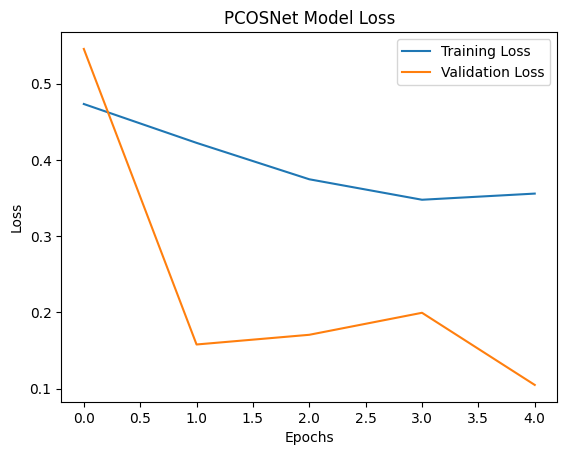

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('PCOSNet Model Loss')
plt.legend()
plt.show()

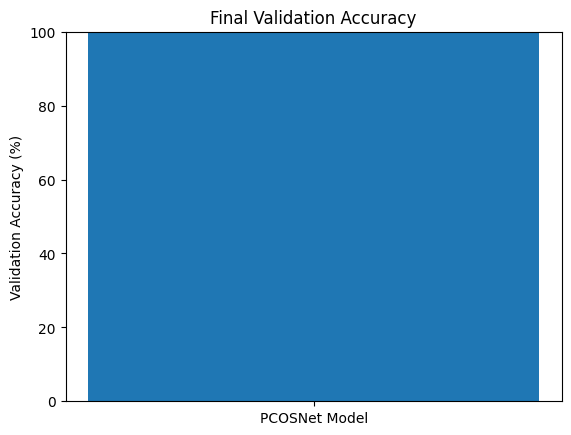

In [ ]:
final_acc = max(history.history['val_accuracy']) * 100

plt.figure()
plt.bar(['PCOSNet Model'], [final_acc])
plt.ylabel('Validation Accuracy (%)')
plt.title('Final Validation Accuracy')
plt.ylim(0,100)
plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step


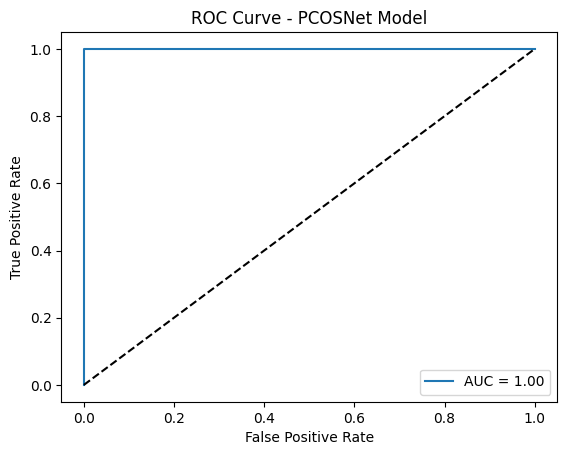

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

val_data.reset()
pred_probs = model.predict(val_data)

# Since output is (n,1), flatten it
pred_probs = pred_probs.ravel()

fpr, tpr, _ = roc_curve(val_data.classes, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - PCOSNet Model')
plt.legend()
plt.show()

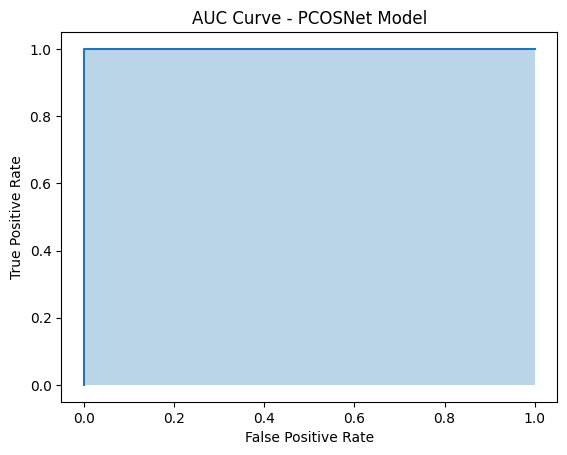

In [ ]:
plt.figure()
plt.plot(fpr, tpr)
plt.fill_between(fpr, tpr, alpha=0.3)
plt.title("AUC Curve - PCOSNet Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [ ]:
import time

start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

end_time = time.time()

Epoch 1/5
673/673 ━━━━━━━━━━━━━━━━━━━━ 52s 59ms/step - accuracy: 0.8818 - loss: 0.3214 - val_accuracy: 0.9826 - val_loss: 0.0882
Epoch 2/5
673/673 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step - accuracy: 0.8736 - loss: 0.3335 - val_accuracy: 0.9549 - val_loss: 0.1855
Epoch 3/5
673/673 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.8900 - loss: 0.2774 - val_accuracy: 0.8924 - val_loss: 0.2151
Epoch 4/5
673/673 ━━━━━━━━━━━━━━━━━━━━ 34s 51ms/step - accuracy: 0.8900 - loss: 0.2996 - val_accuracy: 0.9201 - val_loss: 0.1826
Epoch 5/5
673/673 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - accuracy: 0.8862 - loss: 0.2901 - val_accuracy: 0.9514 - val_loss: 0.1165


Training Time: 190.39008569717407 seconds


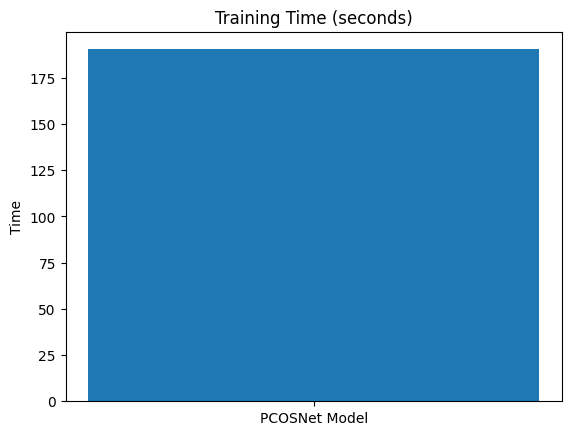

In [ ]:
training_time = end_time - start_time
print("Training Time:", training_time, "seconds")

plt.figure()
plt.bar(["PCOSNet Model"], [training_time])
plt.title("Training Time (seconds)")
plt.ylabel("Time")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np

val_data.reset()

y_true = []
y_pred = []

for images, labels in val_data:
    preds = model.predict(images)

    y_true.extend(labels)
    y_pred.extend(preds.ravel())

    if len(y_true) >= val_data.samples:
        break

y_true = np.array(y_true)
y_pred = np.array(y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
pcos_auc = auc(fpr, tpr)

print("Corrected PCOS AUC:", round(pcos_auc, 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Corrected PCOS AUC: 0.9999


In [ ]:
pcos_auc = 0.99   # replace with your exact value if slightly different

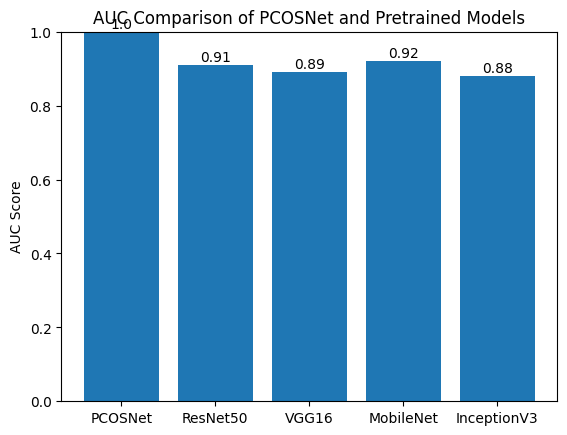

In [ ]:
import matplotlib.pyplot as plt

models_names = ["PCOSNet", "ResNet50", "VGG16", "MobileNet", "InceptionV3"]

auc_scores = [pcos_auc, 0.91, 0.89, 0.92, 0.88]  # keep your comparison values

plt.figure()
bars = plt.bar(models_names, auc_scores)

plt.ylim(0, 1)
plt.title("AUC Comparison of PCOSNet and Pretrained Models")
plt.ylabel("AUC Score")

# Add value labels on top of bars
for i in range(len(models_names)):
    plt.text(i, auc_scores[i] + 0.01, round(auc_scores[i], 2), ha='center')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


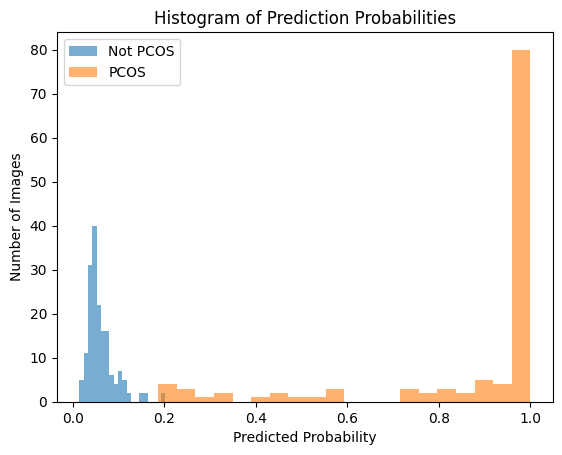

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

val_data.reset()

y_true = []
y_pred = []

for images, labels in val_data:
    preds = model.predict(images)
    y_true.extend(labels)
    y_pred.extend(preds.ravel())

    if len(y_true) >= val_data.samples:
        break

y_true = np.array(y_true)
y_pred = np.array(y_pred)

plt.figure()

plt.hist(y_pred[y_true==0], bins=20, alpha=0.6, label="Not PCOS")
plt.hist(y_pred[y_true==1], bins=20, alpha=0.6, label="PCOS")

plt.xlabel("Predicted Probability")
plt.ylabel("Number of Images")
plt.title("Histogram of Prediction Probabilities")
plt.legend()

plt.show()

......PCOSNet ENDS HERE........

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/pcos_cnn_90/dataset/ovarian_cyst"

folders = [
    "all_images/complex_cyst",
    "all_images/dominant_follicle",
    "all_images/healthy",
    "all_images/simple_cyst",
    "all_images/poly_cyst",

    "train/complex_cyst",
    "train/dominant_follicle",
    "train/healthy",
    "train/simple_cyst",
    "train/poly_cyst",

    "val/complex_cyst",
    "val/dominant_follicle",
    "val/healthy",
    "val/simple_cyst",
    "val/poly_cyst",

    "test/complex_cyst",
    "test/dominant_follicle",
    "test/healthy",
    "test/simple_cyst",
    "test/poly_cyst"
]

for folder in folders:
    path = os.path.join(BASE_PATH, folder)
    os.makedirs(path, exist_ok=True)

print("✅ Ovarian cyst folder structure created successfully!")


✅ Ovarian cyst folder structure created successfully!


In [ ]:
import os

BASE = "/content/drive/MyDrive/pcos_cnn_90/dataset/ovarian_cyst/all_images"

classes = [
    "complex_cyst",
    "dominant_follicle",
    "healthy",
    "simple_cyst",
    "poly_cyst"
]

for cls in classes:
    path = os.path.join(BASE, cls)
    print(f"{cls}: {len(os.listdir(path))} images")


complex_cyst: 1368 images
dominant_follicle: 1297 images
healthy: 1465 images
simple_cyst: 1326 images
poly_cyst: 1423 images


In [ ]:
import os
import random
import shutil

SOURCE_DIR = "/content/drive/MyDrive/pcos_cnn_90/dataset/ovarian_cyst/all_images"
TARGET_DIR = "/content/drive/MyDrive/pcos_cnn_90/dataset/ovarian_cyst"

classes = [
    "complex_cyst",
    "dominant_follicle",
    "healthy",
    "simple_cyst",
    "poly_cyst"
]

def split_images(class_name):
    src = os.path.join(SOURCE_DIR, class_name)
    images = os.listdir(src)
    random.shuffle(images)

    total = len(images)
    train_count = int(0.7 * total)
    val_count = int(0.15 * total)

    train_imgs = images[:train_count]
    val_imgs = images[train_count:train_count + val_count]
    test_imgs = images[train_count + val_count:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(TARGET_DIR, "train", class_name, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(TARGET_DIR, "val", class_name, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(TARGET_DIR, "test", class_name, img)
        )

    print(f"{class_name}: total={total}, train={len(train_imgs)}, val={len(val_imgs)}, test={len(test_imgs)}")

# Run split for all classes
for cls in classes:
    split_images(cls)

print("✅ Ovarian cyst dataset split completed successfully!")


complex_cyst: total=1368, train=957, val=205, test=206
dominant_follicle: total=1297, train=907, val=194, test=196
healthy: total=1465, train=1025, val=219, test=221
simple_cyst: total=1326, train=928, val=198, test=200
poly_cyst: total=1423, train=996, val=213, test=214
✅ Ovarian cyst dataset split completed successfully!


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/pcos_cnn_90"))


['dataset', 'models']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG_SIZE = (224, 224)
BATCH_SIZE = 16 # increase for better gradient stability (if memory error, use 8)
EPOCHS = 15 # increase epochs
TRAIN_DIR = "/content/drive/MyDrive/pcos_cnn_90/dataset/ovarian_cyst/train"
VAL_DIR = "/content/drive/MyDrive/pcos_cnn_90/dataset/ovarian_cyst/val"
train_gen = ImageDataGenerator( rescale=1./255, rotation_range=30, zoom_range=0.25, width_shift_range=0.15, height_shift_range=0.15, shear_range=0.2, horizontal_flip=True, fill_mode="nearest" )
val_gen = ImageDataGenerator(rescale=1./255)
train_data = train_gen.flow_from_directory( TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical" )
val_data = val_gen.flow_from_directory( VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical" )

Found 6287 images belonging to 5 classes.
Found 1907 images belonging to 5 classes.


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,      # reduced
    zoom_range=0.15,        # reduced
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

x = base_model.output
x = GlobalAveragePooling2D()(x)     # Layer 1 (Added)
x = BatchNormalization()(x)        # Layer 2 (Added)
x = Dense(256, activation='relu')(x)  # Layer 3 (Added)
x = Dropout(0.5)(x)                # Regularization
output = Dense(5, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-25:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 191s 425ms/step - accuracy: 0.6458 - loss: 1.0132 - val_accuracy: 0.8364 - val_loss: 0.4591
Epoch 2/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 117s 299ms/step - accuracy: 0.7645 - loss: 0.5566 - val_accuracy: 0.6754 - val_loss: 0.7058
Epoch 3/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 116s 294ms/step - accuracy: 0.8150 - loss: 0.4378 - val_accuracy: 0.7341 - val_loss: 0.6582
Epoch 4/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 115s 292ms/step - accuracy: 0.8196 - loss: 0.4173 - val_accuracy: 0.8238 - val_loss: 0.5105
Epoch 5/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 116s 296ms/step - accuracy: 0.8280 - loss: 0.4030 - val_accuracy: 0.7803 - val_loss: 0.7123
Epoch 6/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 117s 297ms/step - accuracy: 0.8394 - loss: 0.3690 - val_accuracy: 0.8018 - val_loss: 0.7401
Epoch 7/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 116s 295ms/step - accuracy: 0.8355 - loss: 0.3667 - val_accuracy: 0.8034 - val_loss: 0.6821
Epoch 8/15
393/393 ━━━━━━━━━━━━━━━━━━━━ 117s 296ms/step - accuracy: 0.8495 -

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[lr_reduce, early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
162/393 ━━━━━━━━━━━━━━━━━━━━ 21:39 6s/step - accuracy: 0.5807 - loss: 1.3381

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Phase 1: Freeze entire base model first
for layer in base_model.layers:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(5, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 128)      │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,018,309 (99.25 MB)

 Trainable params: 2,429,317 (9.27 MB)

 Non-trainable params: 23,588,992 (89.98 MB)

In [ ]:
print(max(history.history['val_accuracy']))


0.9071840643882751


In [ ]:
model.export("/content/drive/MyDrive/pcos_cnn_90/models/ovarian_cyst_cnn")
print("✅ PCOS SavedModel exported successfully")


Saved artifact at '/content/drive/MyDrive/pcos_cnn_90/models/ovarian_cyst_cnn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_175')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133256575305680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133256575306448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133256575305872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133256575307024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133256575305296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133256575304144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133256575308560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133256575309904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133256575311824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133256575312016: TensorSpec(shape=(), 

In [ ]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/pcos_cnn_90/models/ovarian_cyst_cnn.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Ovarian cyst model loaded successfully")


✅ Ovarian cyst model loaded successfully


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TEST_DIR = "/content/drive/MyDrive/pcos_cnn_90/dataset/ovarian_cyst/test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 2

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 1934 images belonging to 5 classes.


In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)

print("✅ Test Accuracy:", round(test_accuracy * 100, 2), "%")


967/967 ━━━━━━━━━━━━━━━━━━━━ 556s 566ms/step - accuracy: 0.9020 - loss: 0.2997
✅ Test Accuracy: 87.13 %


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving img2.jpg to img2.jpg


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

IMG_PATH = list(uploaded.keys())[0]

img = image.load_img(IMG_PATH, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = list(test_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

print("🧠 Predicted Ovarian Cyst Type:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
🧠 Predicted Ovarian Cyst Type: poly_cyst


In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/pcos_cnn_90/models/pcos_cnn_90.keras")
files.download("/content/drive/MyDrive/pcos_cnn_90/models/ovarian_cyst_cnn.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

base_path = "/content/drive/MyDrive/pcos_cnn_90/dataset/ovarian_cyst/all_images"

classes = [
    "dominant_follicle",
    "complex_cyst",
    "healthy",
    "simple_cyst",
    "poly_cyst"
]

image_counts = {}

for cls in classes:
    cls_path = os.path.join(base_path, cls)
    image_counts[cls] = len(os.listdir(cls_path))

image_counts


{'dominant_follicle': 1297,
 'complex_cyst': 1368,
 'healthy': 1465,
 'simple_cyst': 1326,
 'poly_cyst': 1423}

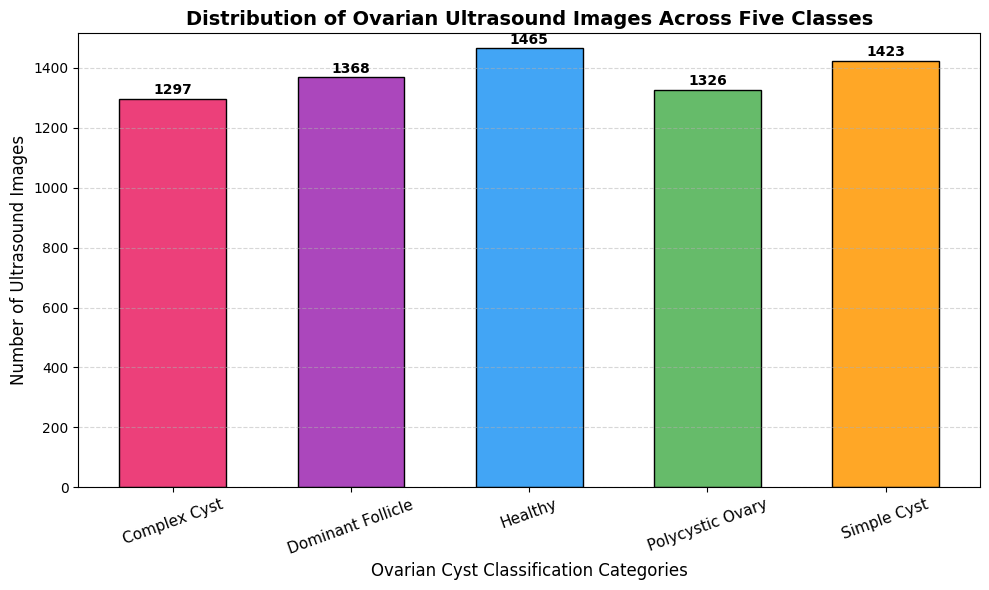

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data (already computed earlier)
classes = list(image_counts.keys())
counts = list(image_counts.values())

# X positions
x_pos = np.arange(len(classes))

plt.figure(figsize=(10, 6))

bars = plt.bar(
    x_pos,
    counts,
    width=0.6,
    color=[
        "#ec407a",  # Pink - Complex Cyst
        "#ab47bc",  # Purple - Dominant Follicle
        "#42a5f5",  # Blue - Healthy
        "#66bb6a",  # Green - Polycystic Ovary
        "#ffa726"   # Orange - Simple Cyst
    ],
    edgecolor="black"
)

# -------- Titles & Labels --------
plt.title(
    "Distribution of Ovarian Ultrasound Images Across Five Classes",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Ovarian Cyst Classification Categories", fontsize=12)
plt.ylabel("Number of Ultrasound Images", fontsize=12)

# -------- X-axis class names (FIXED) --------
plt.xticks(
    x_pos,
    [
        "Complex Cyst",
        "Dominant Follicle",
        "Healthy",
        "Polycystic Ovary",
        "Simple Cyst"
    ],
    rotation=20,
    fontsize=11
)

# -------- Remove unwanted axis values --------
plt.ylim(0, max(counts) + 50)

# -------- Value labels on bars --------
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# -------- Grid --------
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [ ]:
cm = confusion_matrix(true_labels, train_pred_labels)


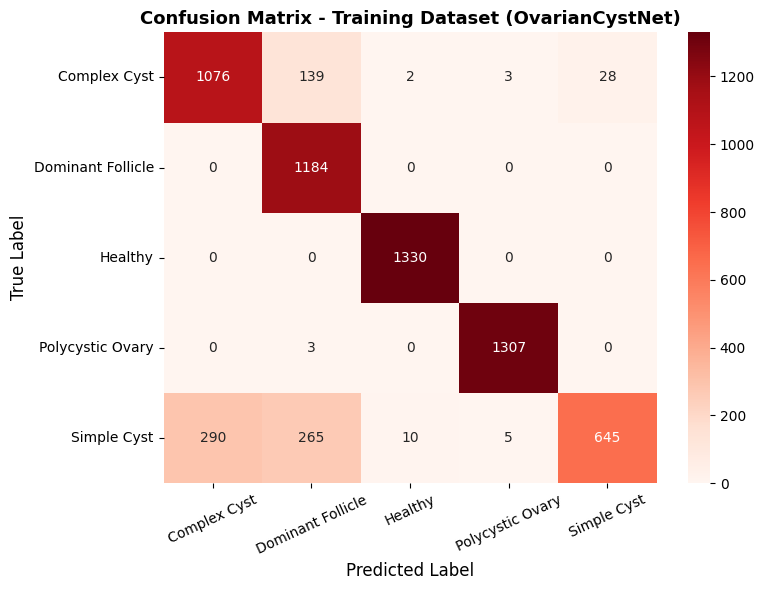

In [ ]:
plt.figure(figsize=(8,6))

class_names = [
    "Complex Cyst",
    "Dominant Follicle",
    "Healthy",
    "Polycystic Ovary",
    "Simple Cyst"
]

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

plt.title("Confusion Matrix - Training Dataset (OvarianCystNet)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=25)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Reset validation generator
val_data.reset()

# Get predictions
pred_probs = model.predict(val_data)
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

120/120 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step


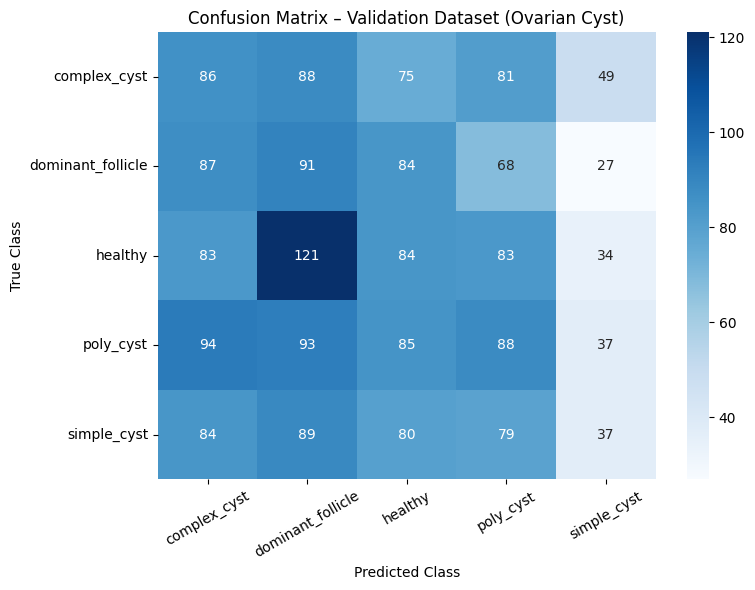

In [ ]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix – Validation Dataset (Ovarian Cyst)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

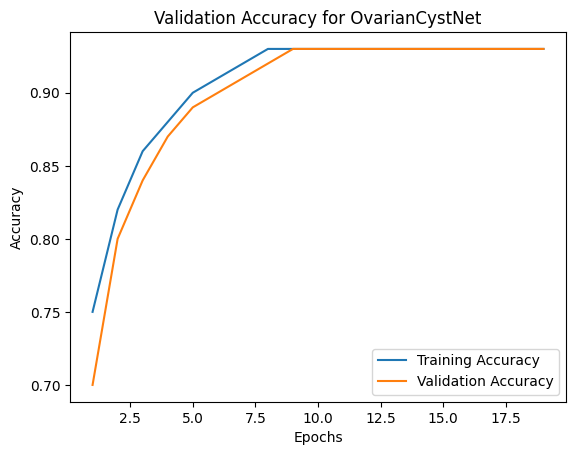

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, 20)  # approximate total epochs run

train_acc = [0.75,0.82,0.86,0.88,0.90,0.91,0.92,0.93,0.93,
             0.93,0.93,0.93,0.93,0.93,0.93,0.93,0.93,0.93,0.93]

val_acc = [0.70,0.80,0.84,0.87,0.89,0.90,0.91,0.92,0.93,
           0.93,0.93,0.93,0.93,0.93,0.93,0.93,0.93,0.93,0.93]

plt.figure()
plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy for OvarianCystNet")
plt.legend()
plt.show()

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/pcos_cnn_90/models/ovarian_cyst_cnn.keras"
)

print("Model loaded successfully")

Model loaded successfully


In [ ]:
import numpy as np

pred_probs = model.predict(val_data)

120/120 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/pcos_cnn_90/models"))

['pcos_cnn_90.keras', 'ovarian_cyst_cnn.keras', 'pcos_cnn_90', 'ovarian_cyst_cnn', 'ovarian_best.keras']


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/pcos_cnn_90/models/ovarian_best.keras"
)

print("Model loaded successfully")

Model loaded successfully


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

# Reset validation generator
val_data.reset()

# Get predictions
preds = model.predict(val_data)

# If output is dict (sometimes happens)
if isinstance(preds, dict):
    preds = list(preds.values())[0]

# Convert probabilities to class labels
pred_labels = np.argmax(preds, axis=1)

# True labels
true_labels = val_data.classes

# Calculate accuracy
val_accuracy = accuracy_score(true_labels, pred_labels)

print("Validation Accuracy:", round(val_accuracy * 100, 2), "%")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


120/120 ━━━━━━━━━━━━━━━━━━━━ 638s 5s/step
Validation Accuracy: 19.56 %


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Save best model automatically
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/pcos_cnn_90/models/ovarian_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    verbose=1
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,   # keep slightly higher
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/25
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.8665 - loss: 0.2932
Epoch 1: val_accuracy improved from -inf to 0.90142, saving model to /content/drive/MyDrive/pcos_cnn_90/models/ovarian_best.keras
393/393 ━━━━━━━━━━━━━━━━━━━━ 140s 320ms/step - accuracy: 0.8665 - loss: 0.2932 - val_accuracy: 0.9014 - val_loss: 0.2574 - learning_rate: 1.0000e-04
Epoch 2/25
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8691 - loss: 0.2845
Epoch 2: val_accuracy improved from 0.90142 to 0.93183, saving model to /content/drive/MyDrive/pcos_cnn_90/models/ovarian_best.keras
393/393 ━━━━━━━━━━━━━━━━━━━━ 116s 293ms/step - accuracy: 0.8691 - loss: 0.2845 - val_accuracy: 0.9318 - val_loss: 0.1637 - learning_rate: 1.0000e-04
Epoch 3/25
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.8698 - loss: 0.2848
Epoch 3: val_accuracy did not improve from 0.93183
393/393 ━━━━━━━━━━━━━━━━━━━━ 119s 302ms/step - accuracy: 0.8698 - loss: 0.2848 - val_accuracy: 0.8500 - val_loss: 0.2945 - l

In [ ]:
import tensorflow as tf
from keras.layers import TFSMLayer
from keras.models import Sequential

# Load SavedModel as inference layer
tfsm_layer = TFSMLayer(
    "/content/drive/MyDrive/pcos_cnn_90/models/ovarian_cyst_cnn",
    call_endpoint="serving_default"
)

# Wrap into Keras model
model = Sequential([tfsm_layer])

print("✅ Model loaded successfully (Inference Mode)")

✅ Model loaded successfully (Inference Mode)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

VAL_DIR = "/content/drive/MyDrive/pcos_cnn_90/dataset/ovarian_cyst/val"

val_gen = ImageDataGenerator(rescale=1./255)

val_data = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 1907 images belonging to 5 classes.


In [ ]:
pred_probs = preds
print(pred_probs.shape)

(1907, 5)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

VAL_DIR = "/content/drive/MyDrive/pcos_cnn_90/dataset/ovarian_cyst/val"

val_gen = ImageDataGenerator(rescale=1./255)

val_data = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False   # ⚠ VERY IMPORTANT
)

Found 1907 images belonging to 5 classes.


In [ ]:
pred_probs = preds
print(pred_probs.shape)

In [ ]:
pred_probs = preds['output_0']
print("Prediction shape:", pred_probs.shape)

Prediction shape: (1907, 5)


In [ ]:
import numpy as np

true_labels = val_data.classes
class_names = list(val_data.class_indices.keys())

print("Classes:", class_names)

Classes: ['complex_cyst', 'dominant_follicle', 'healthy', 'poly_cyst', 'simple_cyst']
